# Chromosome, Replicate 1 Scripting

Create a script to run the deconvolution on each replicate. This notebook will test the script.


In [119]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
from pipeline.fit_replication_profiles import main
from src.utils import mkdir_safe

output_directory = "output/prototype_pipeline_subset_stage2/"


In [327]:
from pipeline.fit_replication_profiles import main as fit_replication_profile
from src.utils import print_fl
from src.config import load_default_chrom_configs, load_cloccs_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

cold_start = False
chrom = 4
replicate = 1
num_epochs = 1
config = None
config, _ = load_cloccs_configs()

np.random.seed(123)

update_params_df, replication_deconvolver, optimizer = fit_replication_profile(chrom=chrom, 
    replicate=replicate, num_epochs=num_epochs, output_directory=output_directory, 
    save=False, config=config,
    learn_subset_parameters=['mu0', 'sigma0', 'gamma2'])

Loading MNase data
Omit windows with less than 75% read coverage.
Running initial iterations...
Deconvolving 702 regions
Initializing B using timepoint 0
Subsetting the cell cycle parameters to learn:  ['mu0', 'sigma0', 'gamma2']
[0] 00:00:00.406, rn=0.0325080964493636
[1] 00:00:00.677, rn=0.005336986859565165
[2] 00:00:00.998, rn=0.004873615021913086
[3] 00:00:01.348, rn=0.004540598217735929
[4] 00:00:01.740, rn=0.004330805574857863
[5] 00:00:02.156, rn=0.0042284662995368165
[6] 00:00:02.490, rn=0.004176609139330678
[7] 00:00:02.810, rn=0.004142511300327905
[8] 00:00:03.075, rn=0.0041229622059889715
[9] 00:00:03.336, rn=0.0041142415857645855
[10] 00:00:03.590, rn=0.004110290274690468
[11] 00:00:03.869, rn=0.004108542848186084
[12] 00:00:04.138, rn=0.004107602850057142
[13] 00:00:04.395, rn=0.004106924785684618
[14] 00:00:04.657, rn=0.0041065117489747435
[15] 00:00:04.969, rn=0.004106258914930721
[16] 00:00:05.325, rn=0.004106006010701572
[17] 00:00:05.638, rn=0.0041058369725573305
[18

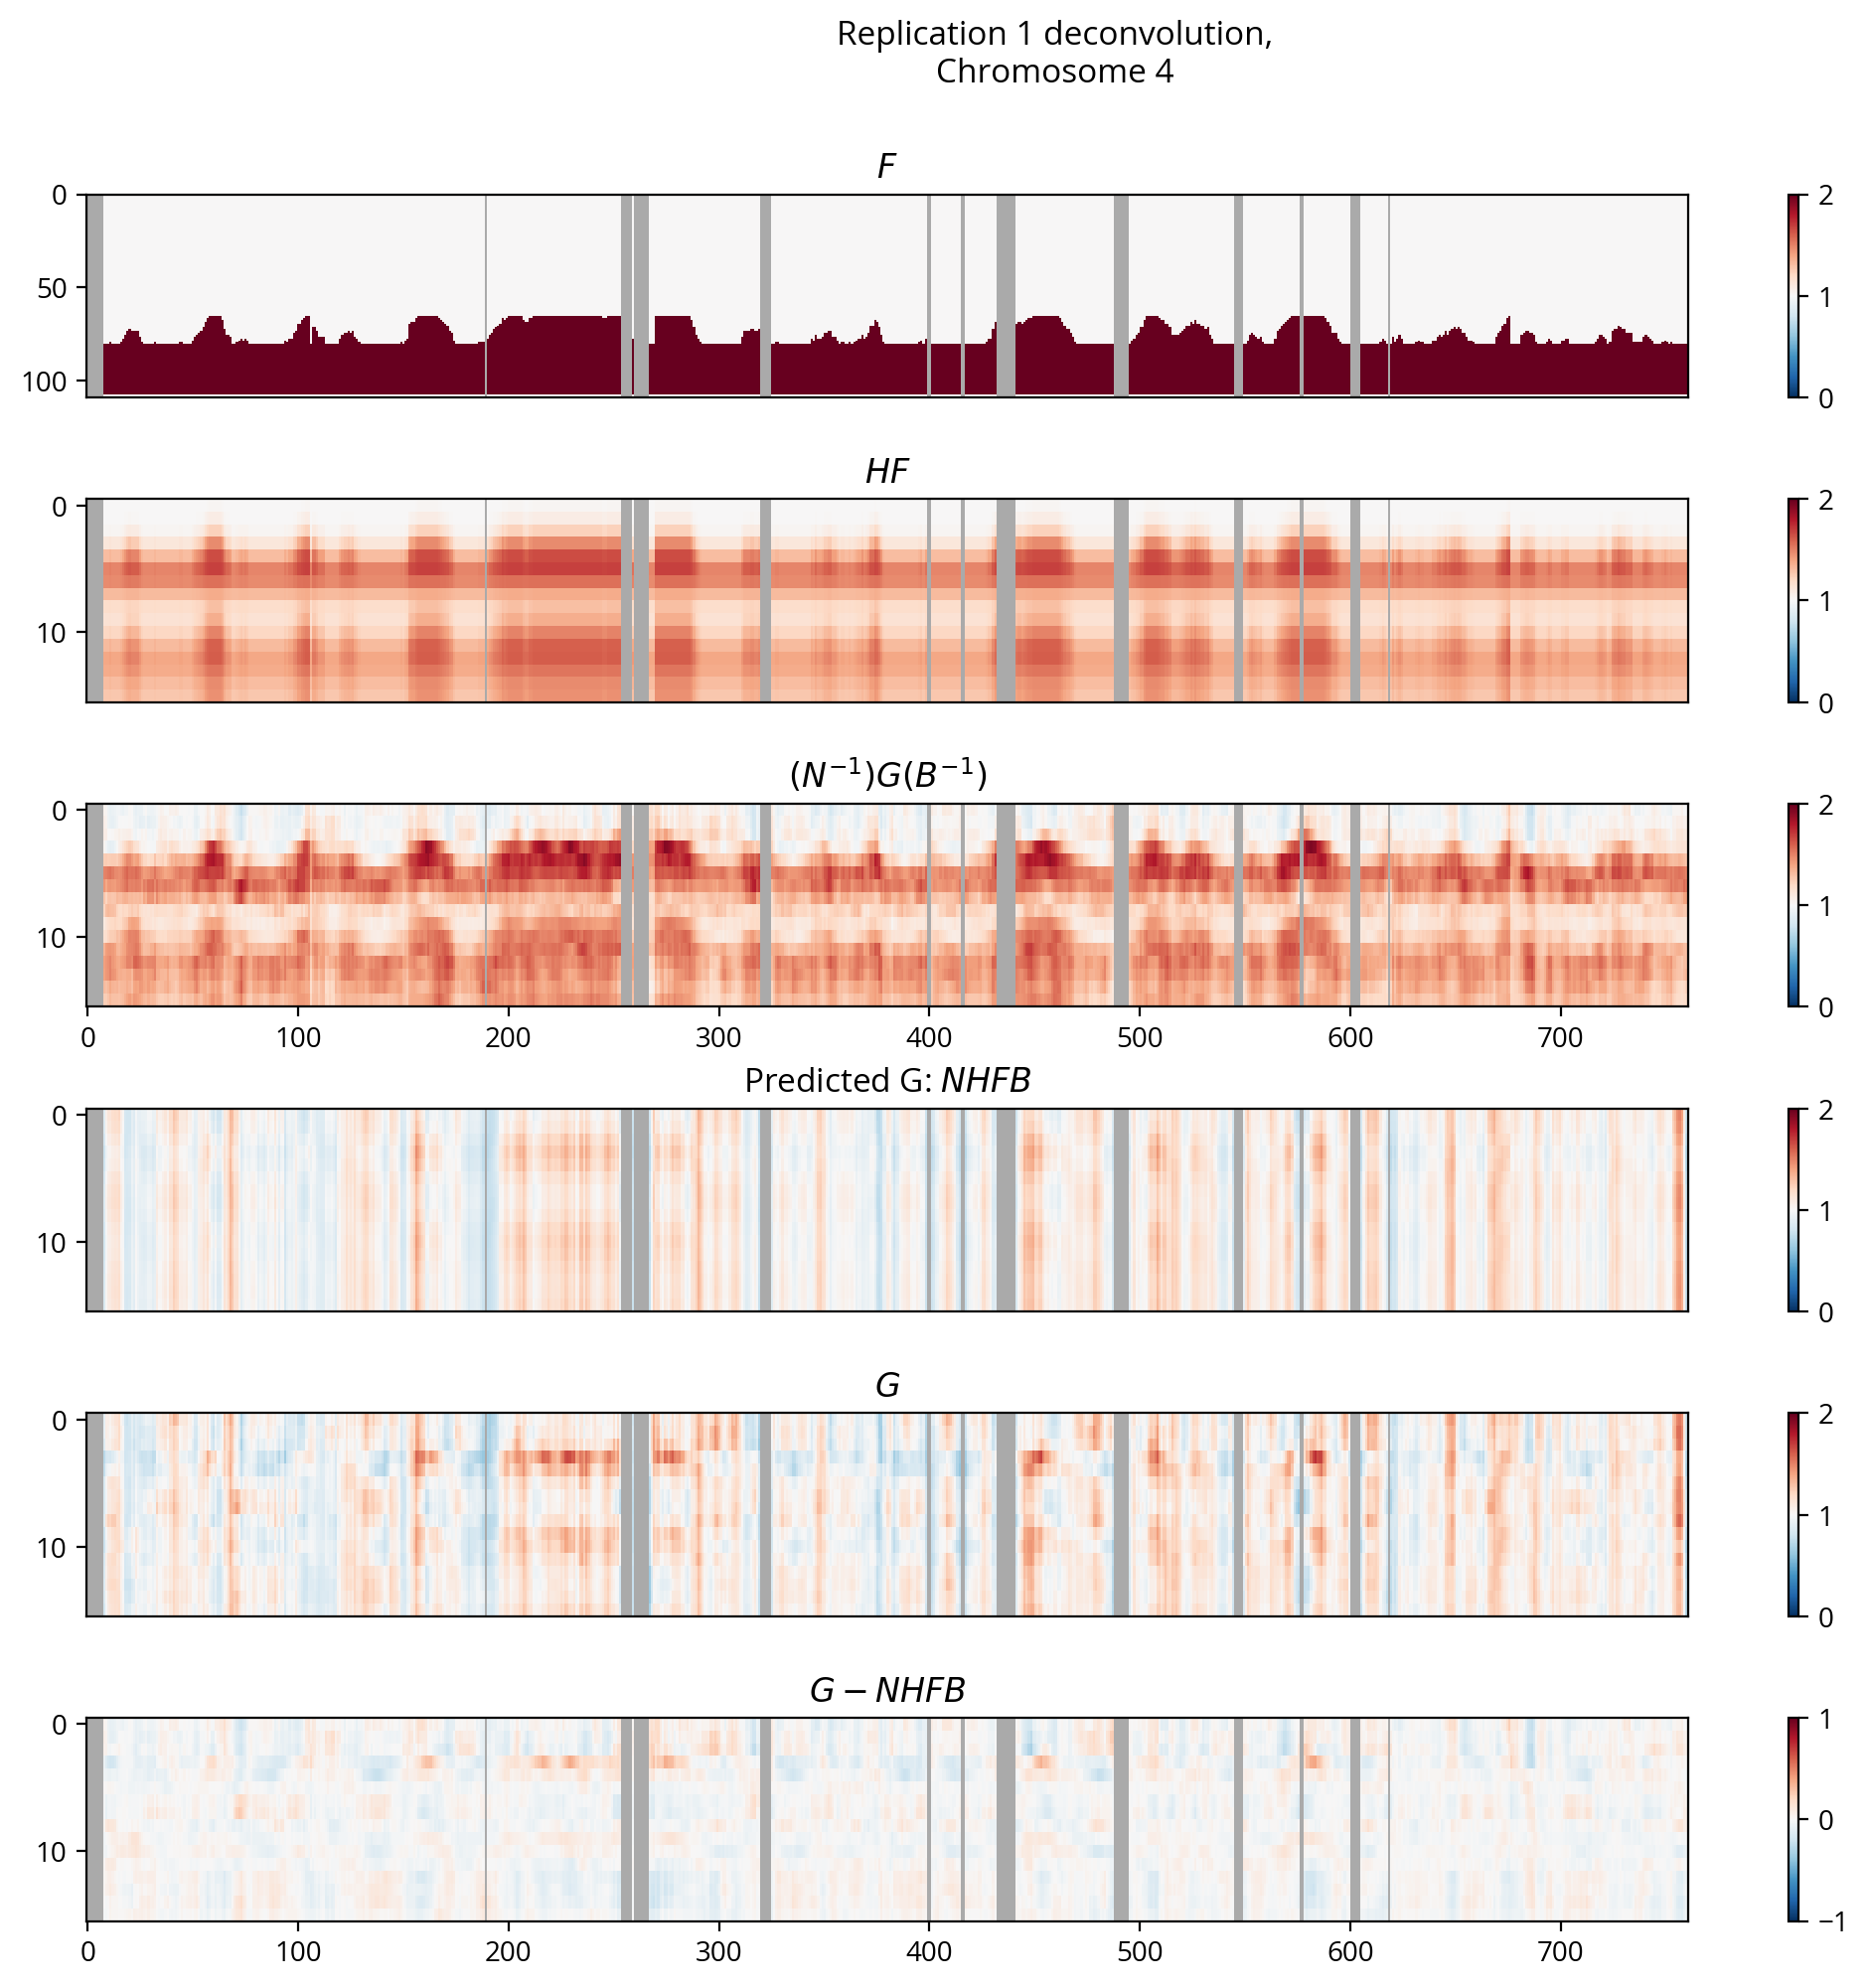

In [328]:
fig = replication_deconvolver.plot_heatmaps()

In [323]:
from src.RealDataReplication import RealDataReplicationDeconvolution

chrom = 4
replicate = 1
num_epochs = 10
config = None
config1, config2 = load_cloccs_configs()

np.random.seed(123)

replication_deconvolver = RealDataReplicationDeconvolution(config, replicate=replicate, 
    chr=chrom)

Omit windows with less than 75% read coverage.


In [292]:
#N_from_runs = np.load('output/draft1_run/single_replication/rep2_chr4_N.npy')
#B_from_runs = pd.read_csv('output/draft1_run/single_replication/rep2_chr4_B.csv')
#B_from_runs = np.diag(B_from_runs[B_from_runs.columns[1:]].values[0])
#B_from_runs=None

In [293]:
plot_parameter_updates

Dictionary saved to output/draft1_run/single_replication/rep2.json
Saved to : output/draft1_run/single_replication/rep2.json


In [294]:
config = config1
replication_deconvolver.setup_deconvolution(config, initial_N=None,
                                           initial_B=NOne)

Deconvolving 704 regions
Initializing B using timepoint 0


In [295]:
replication_deconvolver.iterative_deconvolution_updates(10)

[0] 00:00:00.734, rn=0.012659600958781592
[1] 00:00:01.438, rn=0.0035919517977183635
[2] 00:00:02.316, rn=0.002919167149615637
[3] 00:00:02.997, rn=0.002593719220859602
[4] 00:00:03.720, rn=0.002412529963736569
[5] 00:00:04.690, rn=0.0022904905166061897
[6] 00:00:05.376, rn=0.002206807898848508
[7] 00:00:06.151, rn=0.002146329182367253
[8] 00:00:06.792, rn=0.002108034145816766
[9] 00:00:07.360, rn=0.0020792291296702816


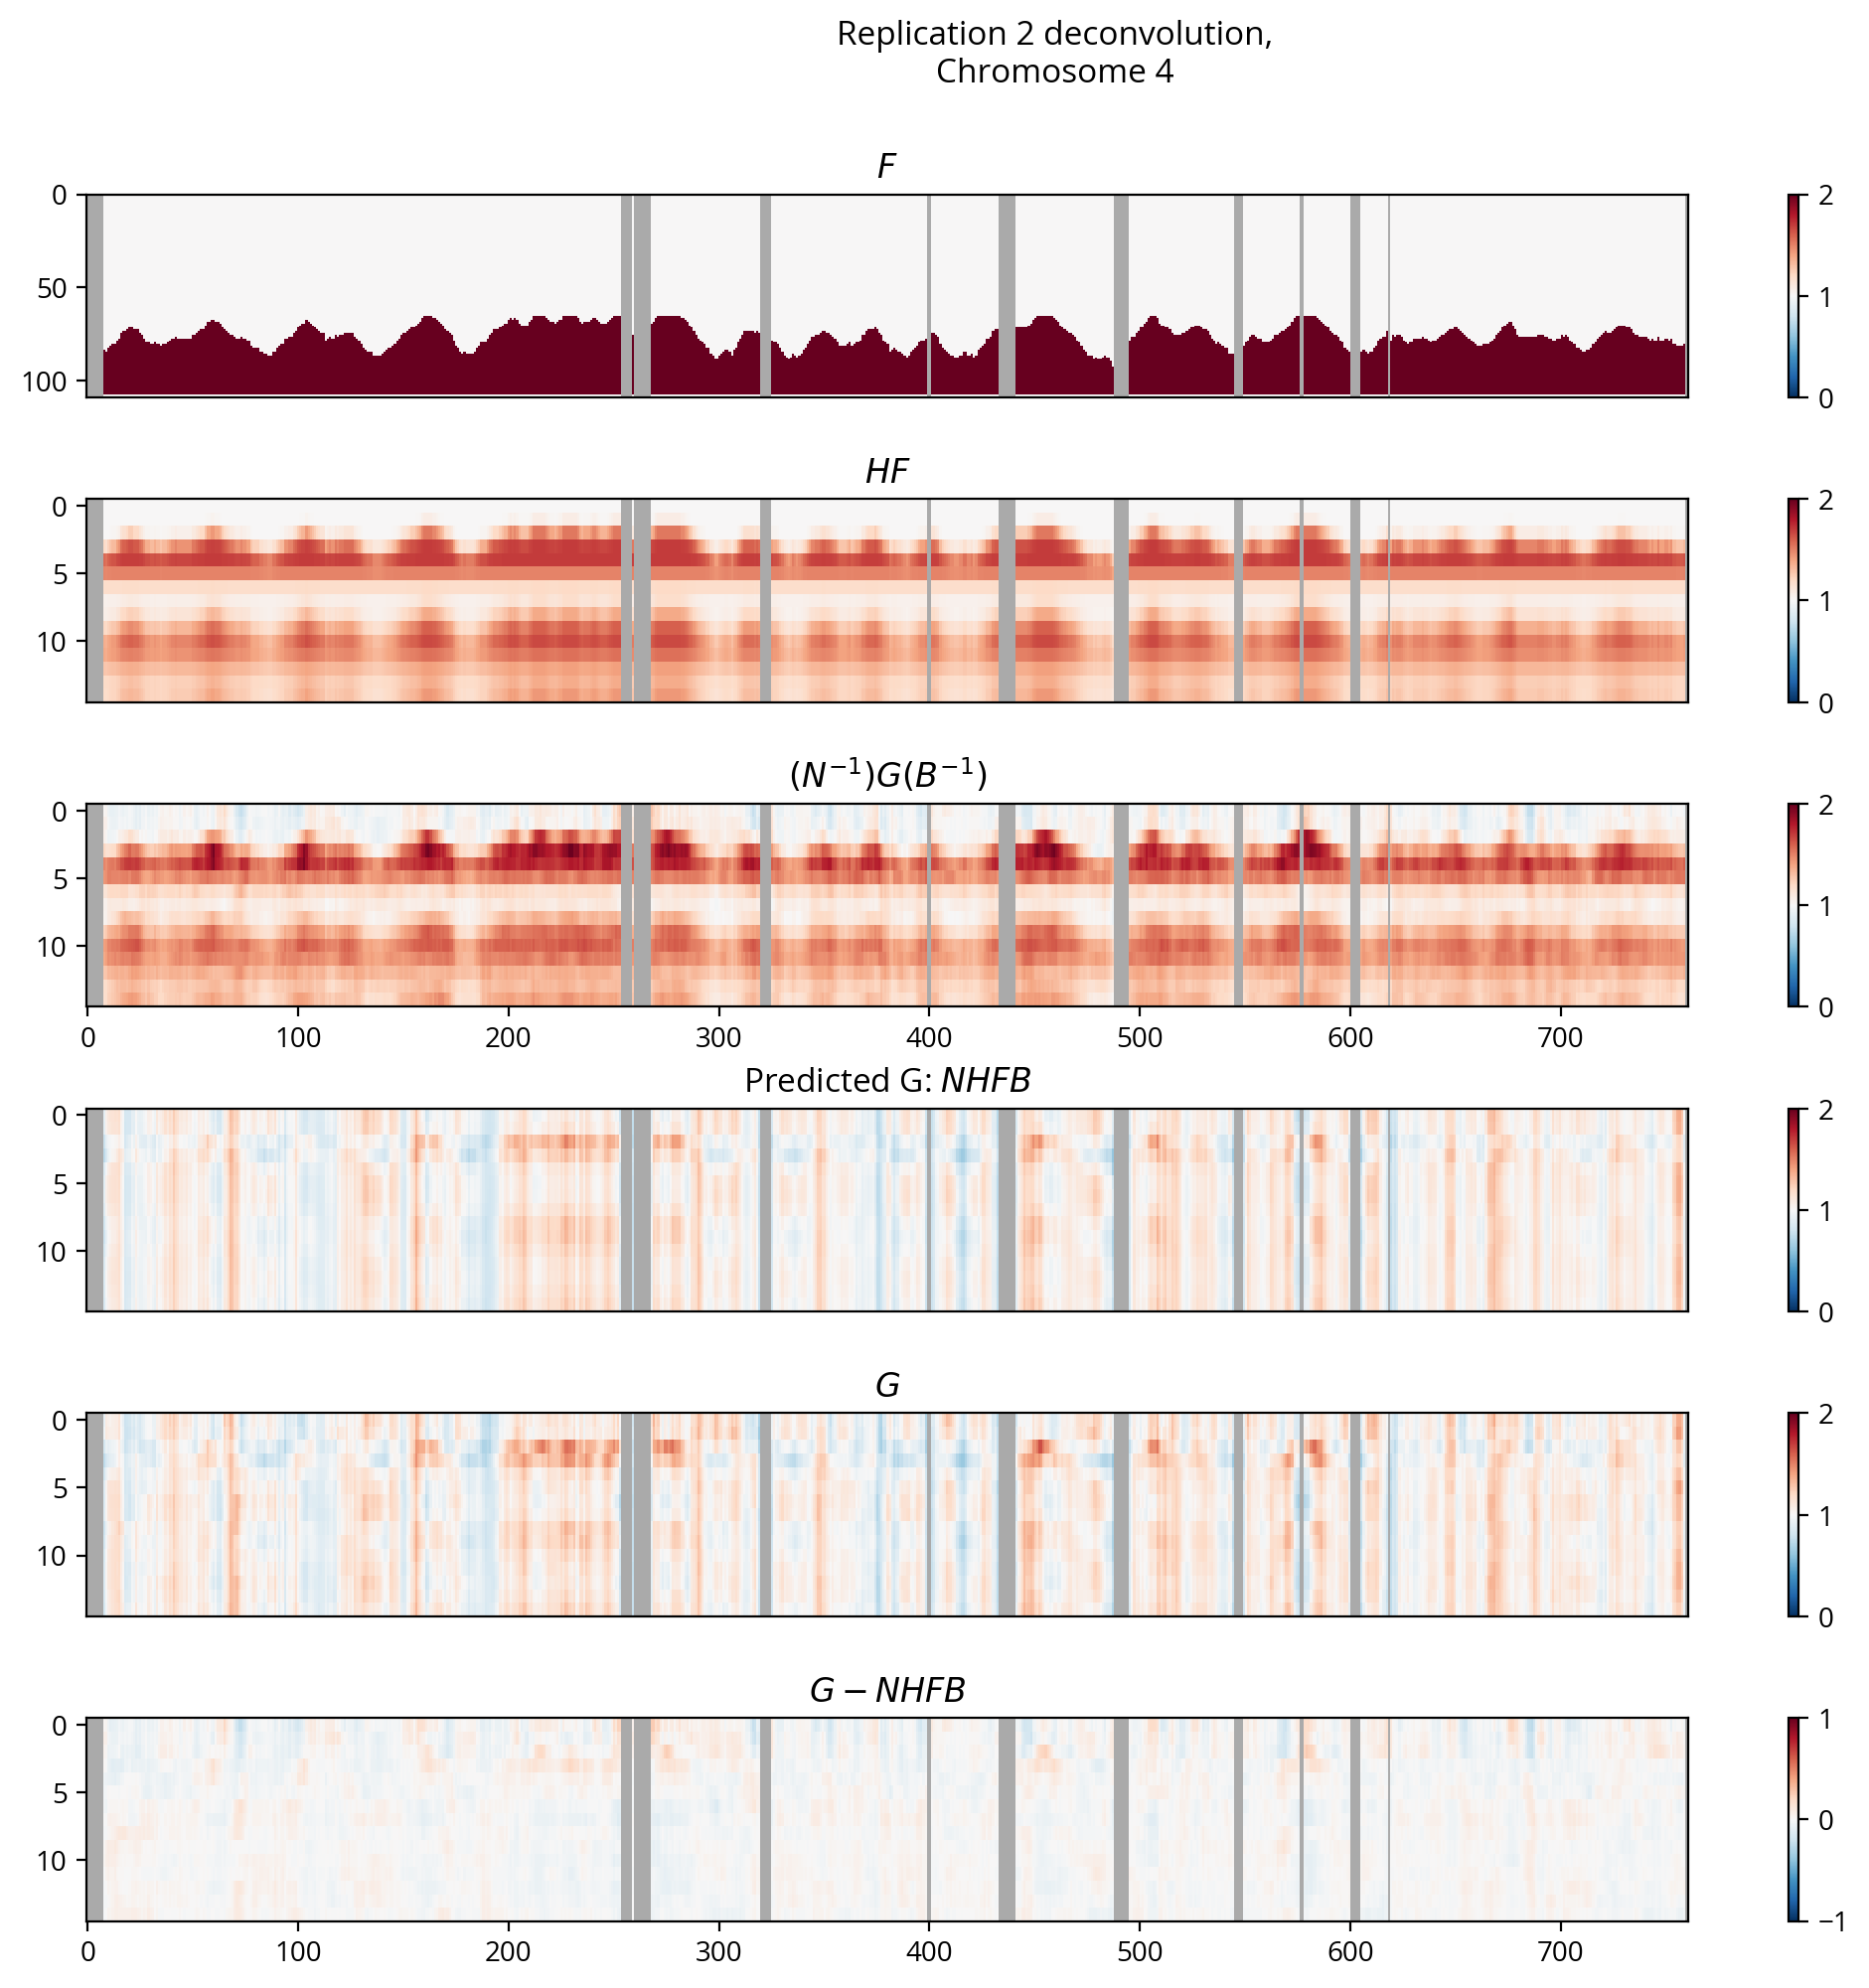

In [296]:
_ = replication_deconvolver.plot_heatmaps()

Text(0, 0.5, 'Average copy number')

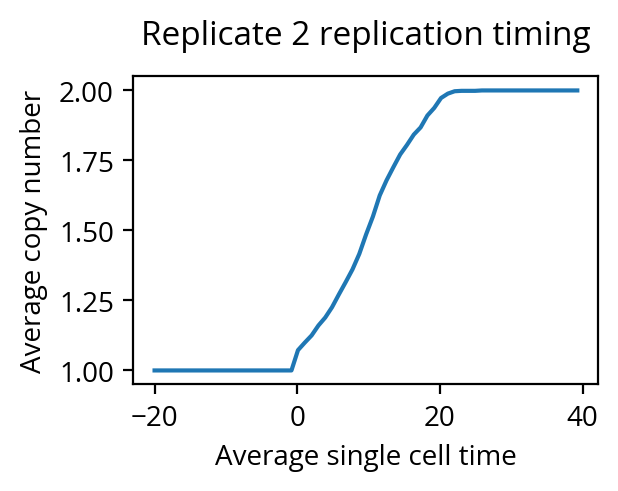

In [318]:
config = replication_deconvolver.config
t_timepoints = config.get_timepoints_for_branch('t')
t_indices = config.get_Hpositions_for_branch('t')
average_copy_number = replication_deconvolver.F.mean(1)
plt.figure(figsize=(3, 2))
plt.plot(t_timepoints, average_copy_number[t_indices])
plt.title(f"Replicate {config.replicate} replication timing", y=1.05)
plt.xlabel("Average single cell time")
plt.ylabel("Average copy number")


In [322]:
from src.optimize_H import compute_estimated_gamma2_from_copy_num, \
    compute_gamma2_l1_loss

compute_gamma2_est_loss(config, replication_deconvolver.F, 1.0) * 0.001

0.0006335170415494269